# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: TRIPLET TEACHER + SIMPLE STUDENT (Low Mem) on: cuda
Loading Data/network_connections.csv...

--- PHASE A: ENGINEERING RICH FEATURES ---
1. NCA (Metric Learning)...
2. Isolation Forests...
3. Autoencoder (Batch Processing)...

--- PHASE B: MANIFOLD MIXUP (CPU Mode) ---
Synthesizing r2l: 796 -> 1000
Synthesizing u2r: 42 -> 1000
Balanced Data Shape: (101940, 60)

--- PHASE C: TRIPLET TEACHER & SIMPLE STUDENT ---
Training Teacher (Triplet + CrossEntropy)...
Teacher Epoch 5 Loss: 0.9306
Teacher Epoch 10 Loss: 0.8220
Teacher Epoch 15 Loss: 0.7758
Teacher Epoch 20 Loss: 0.7189
Teacher Epoch 25 Loss: 0.7020

--- PHASE D: DISTILLING TO SIMPLE STUDENT ---
Student Epoch 10 Loss: 0.0095
Student Epoch 20 Loss: 0.0060
Student Epoch 30 Loss: 0.0056
Student Epoch 40 Loss: 0.0058

--- PHASE E: TUNING INFERENCE (MCC Optimization) ---
Transforming Test Data...
Searching best thresholds (MCC)...
✅ FOUND BEST THRESHOLDS: R2L=0.01, U2R=0.2

   👑 FINAL RESULTS (Triplet + Simple Student): 80.31% (

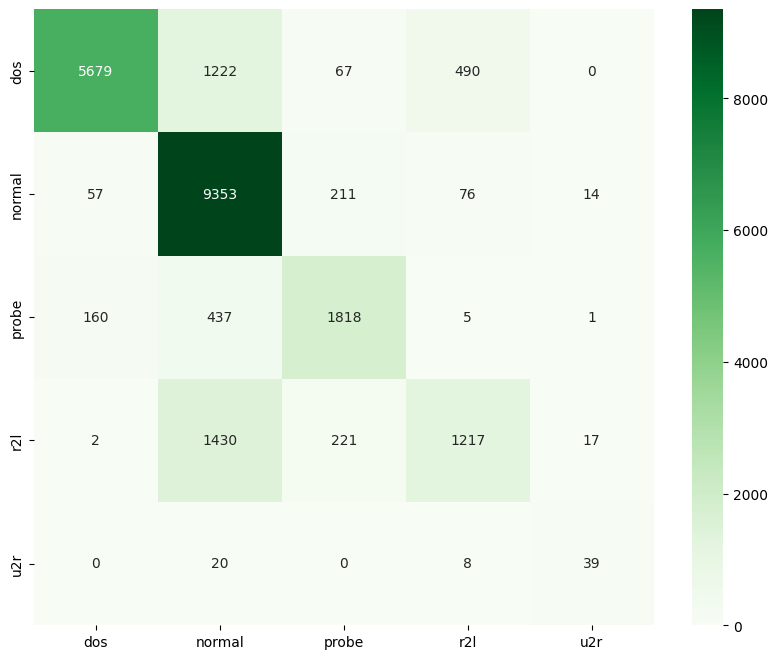

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 PIPELINE: TRIPLET TEACHER + SIMPLE STUDENT (Low Mem) on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

X, y = load_and_prep('Data/network_connections.csv')

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()

del X, y
gc.collect()

# ==========================================
# 2. RICH FEATURE ENGINEERING (Phase A)
# ==========================================
print("\n--- PHASE A: ENGINEERING RICH FEATURES ---")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc = scaler.transform(X_test_raw).astype(np.float32)

print("1. NCA (Metric Learning)...")
nca = NeighborhoodComponentsAnalysis(n_components=15, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(5000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)

print("2. Isolation Forests...")
iso_models = {}
iso_feats_train = []
for cls_idx in np.unique(y_train):
    X_cls = X_train_sc[y_train == cls_idx]
    if len(X_cls) < 50: continue
    iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
    iso.fit(X_cls)
    iso_models[cls_idx] = iso
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))

X_train_iso = np.hstack(iso_feats_train)

print("3. Autoencoder (Batch Processing)...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x): return self.net(x)

ae = Autoencoder(X_train_sc.shape[1]).to(device)
ae_opt = optim.Adam(ae.parameters(), lr=0.005)
ae_loader = DataLoader(TensorDataset(torch.tensor(X_train_sc)), batch_size=512, shuffle=True)

for epoch in range(15):
    for batch in ae_loader:
        x = batch[0].to(device)
        loss = F.mse_loss(ae(x), x)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

def get_recon_error_batched(data):
    ae.eval()
    loader = DataLoader(TensorDataset(torch.tensor(data)), batch_size=2048, shuffle=False)
    errors = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            recon = ae(x)
            err = torch.mean((x - recon)**2, dim=1).cpu().numpy()
            errors.append(err)
    return np.concatenate(errors).reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error_batched(X_train_sc)
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])

del X_train_sc, X_train_nca, X_train_iso, X_train_ae, iso_feats_train
gc.collect()

# ==========================================
# 3. MANIFOLD MIXUP (Phase B)
# ==========================================
print("\n--- PHASE B: MANIFOLD MIXUP (CPU Mode) ---")

def mixup_data_cpu(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.shape[0]
    index = np.random.permutation(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y

X_t = X_train_final 
y_t = y_train 

X_bal_list, y_bal_list = [X_t], [y_t]
TARGET_COUNT = 1000 

for cls_idx in np.unique(y_train):
    mask = (y_train == cls_idx)
    count = mask.sum()
    if count < TARGET_COUNT:
        print(f"Synthesizing {le.classes_[cls_idx]}: {count} -> {TARGET_COUNT}")
        x_rare = X_t[mask]
        y_rare = y_t[mask]
        
        needed = TARGET_COUNT - count
        generated = []
        for _ in range(int(np.ceil(needed / count))):
            mixed_x, _ = mixup_data_cpu(x_rare, y_rare, alpha=0.2)
            generated.append(mixed_x)
            
        gen_data = np.concatenate(generated)[:needed]
        X_bal_list.append(gen_data)
        y_bal_list.append(np.full((needed,), cls_idx))

X_train_bal = np.concatenate(X_bal_list)
y_train_bal = np.concatenate(y_bal_list)
print(f"Balanced Data Shape: {X_train_bal.shape}")

X_train_bal_t = torch.tensor(X_train_bal, dtype=torch.float32)
y_train_bal_t = torch.tensor(y_train_bal, dtype=torch.long)

del X_t, y_t, X_bal_list, y_bal_list
gc.collect()

# ==========================================
# 4. MODELS: TEACHER & SIMPLE STUDENT
# ==========================================
print("\n--- PHASE C: TRIPLET TEACHER & SIMPLE STUDENT ---")

class Mish(nn.Module):
    def forward(self, x): return x * torch.tanh(F.softplus(x))

# 1. THE TRIPLET TEACHER (Complex MLP)
class VectorTeacher(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), Mish(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), Mish(), nn.Dropout(0.2),
            nn.Linear(256, 128) # Embedding
        )
        self.head = nn.Linear(128, out_dim)
    def forward(self, x):
        emb = F.normalize(self.net(x), p=2, dim=1)
        return emb, self.head(emb)

# 2. THE UNATTENTIVE STUDENT (Simple MLP)
class VectorStudent(nn.Module):
    def __init__(self, input_dim, out_dim, embed_dim=128):
        super().__init__()
        # Simple, fast architecture
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), 
            nn.LeakyReLU(), # LeakyReLU is often more stable for simple nets
            nn.Linear(128, embed_dim)
        )
        self.head = nn.Linear(embed_dim, out_dim)

    def forward(self, x):
        emb = F.normalize(self.net(x), p=2, dim=1)
        logits = self.head(emb)
        return emb, logits

# --- TRIPLET LOSS ---
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, embeddings, labels):
        dist_mat = torch.cdist(embeddings, embeddings)
        is_pos = labels.unsqueeze(0) == labels.unsqueeze(1)
        is_pos.fill_diagonal_(False)
        dist_pos = dist_mat.clone()
        dist_pos[~is_pos] = -float('inf')
        hard_pos, _ = dist_pos.max(dim=1)
        is_neg = labels.unsqueeze(0) != labels.unsqueeze(1)
        dist_neg = dist_mat.clone()
        dist_neg[~is_neg] = float('inf')
        hard_neg, _ = dist_neg.min(dim=1)
        return F.relu(hard_pos - hard_neg + self.margin).mean()

train_dl = DataLoader(TensorDataset(X_train_bal_t, y_train_bal_t), batch_size=256, shuffle=True)

# Train Teacher
teacher = VectorTeacher(X_train_final.shape[1], num_classes).to(device)
opt_t = optim.AdamW(teacher.parameters(), lr=0.001)
sched_t = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=25)
crit_triplet = BatchHardTripletLoss(margin=1.0)
crit_ce = nn.CrossEntropyLoss()

print("Training Teacher (Triplet + CrossEntropy)...")
for epoch in range(25):
    teacher.train()
    loss_acc = 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt_t.zero_grad()
        embeds, logits = teacher(x)
        loss = crit_triplet(embeds, y) + crit_ce(logits, y)
        loss.backward()
        opt_t.step()
        loss_acc += loss.item()
    sched_t.step()
    if (epoch+1) % 5 == 0:
        print(f"Teacher Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

# Train Student (Unattentive)
student = VectorStudent(X_train_final.shape[1], num_classes).to(device)
opt_s = optim.AdamW(student.parameters(), lr=0.002)
crit_cls = nn.CrossEntropyLoss()

print("\n--- PHASE D: DISTILLING TO SIMPLE STUDENT ---")
teacher.eval()
for epoch in range(40):
    student.train()
    loss_acc = 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt_s.zero_grad()
        s_emb, s_logits = student(x)
        with torch.no_grad(): t_emb, t_logits = teacher(x)
        
        # Feature Loss (Cosine) + Soft + Hard
        l_feat = (1 - F.cosine_similarity(s_emb, t_emb)).mean()
        l_kd = nn.KLDivLoss(reduction='batchmean')(F.log_softmax(s_logits/4.0, 1), F.softmax(t_logits/4.0, 1)) * 16
        l_cls = crit_cls(s_logits, y)
        
        loss = 0.5*l_feat + 0.3*l_kd + 0.2*l_cls
        loss.backward(); opt_s.step()
        loss_acc += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Student Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 5. VALIDATION & TUNING (MCC)
# ==========================================
print("\n--- PHASE E: TUNING INFERENCE (MCC Optimization) ---")
try:
    NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
    NSL_COLS = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
        'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
        'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
        'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
        'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
        'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
        'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
        'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
        'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
        'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
    ]
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]
    y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    
    print("Transforming Test Data...")
    X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    iso_feats_nsl = []
    for cls_idx in np.sort(list(iso_models.keys())):
        iso_feats_nsl.append(iso_models[cls_idx].decision_function(X_nsl_sc).reshape(-1, 1).astype(np.float32))
    X_nsl_iso = np.hstack(iso_feats_nsl)
    X_nsl_ae = get_recon_error_batched(X_nsl_sc)
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    X_test_tensor_cpu = torch.tensor(X_nsl_final)

    def predict_with_tta_batched(model, x_cpu, n_aug=5, noise=0.02):
        model.eval()
        x_gpu = x_cpu.to(device)
        probs_sum = None
        with torch.no_grad():
            for i in range(n_aug):
                noise_t = torch.randn_like(x_gpu)*noise if i>0 else 0
                _, logits = model(x_gpu + noise_t)
                probs = torch.softmax(logits, dim=1)
                if probs_sum is None: probs_sum = probs
                else: probs_sum += probs
        return (probs_sum / n_aug).cpu().numpy()

    all_probs = []
    loader = DataLoader(TensorDataset(X_test_tensor_cpu), batch_size=2048)
    for bx in loader:
        p = predict_with_tta_batched(student, bx[0], n_aug=5) 
        all_probs.append(p)
    probs_np = np.concatenate(all_probs)
    
    idx_u2r = list(le.classes_).index('u2r')
    idx_r2l = list(le.classes_).index('r2l')
    
    best_score = -1
    best_params = (0, 0)
    
    print("Searching best thresholds (MCC)...")
    for t_r2l in [0.005, 0.01, 0.05, 0.1, 0.2]:
        for t_u2r in [0.005, 0.01, 0.05, 0.1, 0.2]:
            temp_preds = []
            for p in probs_np:
                if p[idx_u2r] > t_u2r: temp_preds.append(idx_u2r)
                elif p[idx_r2l] > t_r2l: temp_preds.append(idx_r2l)
                else: temp_preds.append(np.argmax(p))
            mask = y_nsl_vec != -1
            mcc = matthews_corrcoef(y_nsl_vec[mask], np.array(temp_preds)[mask])
            if mcc > best_score:
                best_score = mcc
                best_params = (t_r2l, t_u2r)
    
    print(f"✅ FOUND BEST THRESHOLDS: R2L={best_params[0]}, U2R={best_params[1]}")
    final_preds = []
    t_r2l, t_u2r = best_params
    for p in probs_np:
        if p[idx_u2r] > t_u2r: final_preds.append(idx_u2r)
        elif p[idx_r2l] > t_r2l: final_preds.append(idx_r2l)
        else: final_preds.append(np.argmax(p))
    final_preds = np.array(final_preds)

    mask = y_nsl_vec != -1
    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    mcc = matthews_corrcoef(y_nsl_vec[mask], final_preds[mask])
    
    print("\n" + "="*40)
    print(f"   👑 FINAL RESULTS (Triplet + Simple Student): {acc:.2%} (MCC: {mcc:.4f}) 👑")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()